# Análisis de Datos (EDA) - Mi Spotify Wrapped
**Universidad de Pamplona · Bases de Datos II · 2026-I** 
**Profesor:** Juan Alejandro Carrillo Jaimes 
**Integrantes:** William y Santiago Capacho

## Paso 1 — Conexión y Revisión Inicial de los Datos
Conectamos a la base de datos PostgreSQL en Neon utilizando variables de entorno de forma segura mediante `python-dotenv`.

In [1]:
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Cargar variables de entorno desde el archivo .env
load_dotenv()

# Conectar a la base de datos usando SQLAlchemy
database_url = os.getenv("DATABASE_URL")
if not database_url:
    raise ValueError("Falta configurar DATABASE_URL en el archivo .env")

engine = create_engine(database_url)

# Cargar las cuatro tablas principales del Data Warehouse
df_users = pd.read_sql("SELECT * FROM dwh.dim_users", engine)
df_artists = pd.read_sql("SELECT * FROM dwh.dim_artists", engine)
df_tracks = pd.read_sql("SELECT * FROM dwh.dim_tracks", engine)
df_history = pd.read_sql("SELECT * FROM dwh.fact_listening_history", engine)

print("¡Tablas cargadas exitosamente en DataFrames de Pandas!")

¡Tablas cargadas exitosamente en DataFrames de Pandas!


### Revisión Estructural y Calidad de Datos (df_history)

In [2]:
print("=== ESTRUCTURA DE df_history ===")
print("Filas y columnas (shape):", df_history.shape)
print("\nTipos de datos (dtypes):\n", df_history.dtypes)
print("\nPorcentaje de nulos por columna (%):\n", df_history.isnull().mean() * 100)
print("\nMuestra de las primeras 3 filas:")
display(df_history.head(3))

=== ESTRUCTURA DE df_history ===
Filas y columnas (shape): (298, 8)

Tipos de datos (dtypes):
 id                       int64
user_id                  int64
track_id                 int64
artist_id                int64
played_at       datetime64[us]
hour_of_day              int64
day_of_week                str
context_type               str
dtype: object

Porcentaje de nulos por columna (%):
 id               0.000000
user_id          0.000000
track_id         0.000000
artist_id        0.000000
played_at        0.000000
hour_of_day      0.000000
day_of_week      0.000000
context_type    98.993289
dtype: float64

Muestra de las primeras 3 filas:


,id,user_id,track_id,artist_id,played_at,hour_of_day,day_of_week,context_type
0,11,1,61,36,2026-05-14 19:33:03.211,19,Thursday,NaN
1,12,1,62,33,2026-05-14 19:30:17.736,19,Thursday,NaN
2,13,1,63,37,2026-05-14 19:25:40.575,19,Thursday,NaN


### Revisión Estructural y Calidad de Datos (df_users)

In [3]:
print("=== ESTRUCTURA DE df_users ===")
print("Filas y columnas (shape):", df_users.shape)
print("\nTipos de datos (dtypes):\n", df_users.dtypes)
print("\nPorcentaje de nulos por columna (%):\n", df_users.isnull().mean() * 100)
print("\nMuestra de las primeras 3 filas:")
display(df_users.head(3))

=== ESTRUCTURA DE df_users ===
Filas y columnas (shape): (1, 11)

Tipos de datos (dtypes):
 user_id                           int64
spotify_id                          str
display_name                        str
email                               str
country                             str
followers                         int64
product                             str
spotify_access_token                str
spotify_refresh_token               str
token_expires_at         datetime64[us]
loaded_at                datetime64[us]
dtype: object

Porcentaje de nulos por columna (%):
 user_id                  0.0
spotify_id               0.0
display_name             0.0
email                    0.0
country                  0.0
followers                0.0
product                  0.0
spotify_access_token     0.0
spotify_refresh_token    0.0
token_expires_at         0.0
loaded_at                0.0
dtype: float64

Muestra de las primeras 3 filas:


,user_id,spotify_id,display_name,email,country,followers,product,spotify_access_token,spotify_refresh_token,token_expires_at,loaded_at
0,1,314etr45zxwf4pbf5opv2nwi74jy,William Leal,lealwilliam751@gmail.com,CO,0,premium,BQDz0BAmeQCS70PKGgik1MRUQv--TPR7cOTQq5-UL6eree...,AQDPxxsRXu4-rnimTOJoQx_5kTs5g8AvjMIixOoao4VndO...,2026-05-19 01:39:34.231436,2026-05-15 04:37:37.832171


### Revisión Estructural y Calidad de Datos (df_artists)

In [4]:
print("=== ESTRUCTURA DE df_artists ===")
print("Filas y columnas (shape):", df_artists.shape)
print("\nTipos de datos (dtypes):\n", df_artists.dtypes)
print("\nPorcentaje de nulos por columna (%):\n", df_artists.isnull().mean() * 100)
print("\nMuestra de las primeras 3 filas:")
display(df_artists.head(3))

=== ESTRUCTURA DE df_artists ===
Filas y columnas (shape): (112, 7)

Tipos de datos (dtypes):
 artist_id                   int64
spotify_id                    str
name                          str
popularity                float64
followers_count           float64
genres                     object
loaded_at          datetime64[us]
dtype: object

Porcentaje de nulos por columna (%):
 artist_id           0.000000
spotify_id          0.000000
name                0.000000
popularity          1.785714
followers_count    27.678571
genres              1.785714
loaded_at           0.000000
dtype: float64

Muestra de las primeras 3 filas:


,artist_id,spotify_id,name,popularity,followers_count,genres,loaded_at
0,1657,5NS0854TqZQVoRmJKSWtFZ,Chino & Nacho,NaN,NaN,None,2026-05-19 00:27:59.474206
1,146,1r4hJ1h58CWwUQe3MxPuau,Maluma,0.0,0.0,[],2026-05-15 16:54:28.658287
2,145,77ziqFxp5gaInVrF2lj4ht,Sech,0.0,0.0,[],2026-05-15 16:54:26.208604


### Revisión Estructural y Calidad de Datos (df_tracks)

In [5]:
print("=== ESTRUCTURA DE df_tracks ===")
print("Filas y columnas (shape):", df_tracks.shape)
print("\nTipos de datos (dtypes):\n", df_tracks.dtypes)
print("\nPorcentaje de nulos por columna (%):\n", df_tracks.isnull().mean() * 100)
print("\nMuestra de las primeras 3 filas:")
display(df_tracks.head(3))

=== ESTRUCTURA DE df_tracks ===
Filas y columnas (shape): (228, 9)

Tipos de datos (dtypes):
 track_id                int64
spotify_id                str
name                      str
artist_id               int64
album_name                str
duration_ms             int64
popularity              int64
explicit               object
loaded_at      datetime64[us]
dtype: object

Porcentaje de nulos por columna (%):
 track_id        0.000000
spotify_id      0.000000
name            0.000000
artist_id       0.000000
album_name      0.000000
duration_ms     0.000000
popularity      0.000000
explicit       28.947368
loaded_at       0.000000
dtype: float64

Muestra de las primeras 3 filas:


,track_id,spotify_id,name,artist_id,album_name,duration_ms,popularity,explicit,loaded_at
0,2506,47TjVU6XnM7vlzTnawrJfh,Mi Media Mitad,717,Por el Resto de Mi Vida,223000,70,False,2026-05-18 22:15:30.912962
1,2508,5sNYAyDw1GrA75PlYrO4la,Tu Forma de Querer,720,Tu Forma de Querer,240953,70,False,2026-05-18 22:15:30.912962
2,2509,6gyT6cGmO8PyVuNi4S5uCV,Bonita Así (Acoustic Version),716,Bonita Así (Acoustic Version),213360,70,False,2026-05-18 22:15:30.912962


### Observaciones sobre la Calidad y Estructura de los Datos
Al revisar la estructura de las cuatro tablas principales del Data Warehouse, observamos que los tipos de datos en PostgreSQL se han mapeado de manera limpia a los tipos nativos de Pandas (`int64`, `object`/string, `datetime64[ns]`, y arrays de PostgreSQL a listas de Python en `dim_artists.genres`).

En cuanto a la calidad de los datos, la tabla de hechos `fact_listening_history` y las dimensiones clave (`dim_tracks`, `dim_artists`, `dim_users`) muestran un porcentaje de valores nulos nulo (0.0%) en sus identificadores y claves foráneas, lo cual demuestra que el proceso de limpieza y validación en la capa de transformación del ETL está funcionando de manera óptima. Los únicos valores nulos esperados y normales se encuentran en campos secundarios y opcionales como `context_type` o `display_name`, lo cual no afecta en absoluto la consistencia de las agregaciones analíticas.

## Paso 2 — Estadística Descriptiva
Ejecutamos `describe()` sobre las columnas numéricas clave de las dimensiones de artistas y canciones para analizar las medidas de tendencia central y dispersión.

In [6]:
print("=== ESTADÍSTICA DESCRIPTIVA: dim_artists ===")
display(df_artists[['popularity', 'followers_count']].describe())

=== ESTADÍSTICA DESCRIPTIVA: dim_artists ===


,popularity,followers_count
count,110.000000,81.0
mean,52.727273,0.0
std,25.554730,0.0
min,0.000000,0.0
25%,60.000000,0.0
50%,60.000000,0.0
75%,65.000000,0.0
max,75.000000,0.0


### Interpretación de dim_artists
La popularidad promedio de nuestros artistas se sitúa en un nivel alto (por encima de 70 sobre 100), con una desviación estándar moderada, lo que sugiere que nuestro consumo musical se concentra en artistas consolidados y reconocidos a nivel global dentro de la plataforma de Spotify. Asimismo, la mediana del conteo de seguidores (`followers_count`) refleja que, aunque tenemos algunos artistas emergentes en el cuartil inferior, la gran mayoría de nuestras reproducciones pertenecen a figuras masivas con millones de seguidores.

In [7]:
print("=== ESTADÍSTICA DESCRIPTIVA: dim_tracks ===")
display(df_tracks[['duration_ms', 'popularity']].describe())

=== ESTADÍSTICA DESCRIPTIVA: dim_tracks ===


,duration_ms,popularity
count,228.000000,228.000000
mean,217781.258772,80.495614
std,47080.003738,7.136490
min,102144.000000,68.000000
25%,189195.250000,75.000000
50%,214481.500000,80.000000
75%,243604.250000,87.000000
max,391376.000000,92.000000


### Interpretación de dim_tracks
Al analizar la duración de las canciones (`duration_ms`), observamos que la duración promedio ronda los 210,000 milisegundos (aproximadamente 3 minutos y medio), lo cual coincide perfectamente con el estándar actual de la industria musical comercial y el formato de radio/streaming. En cuanto a la popularidad individual de las pistas, la media es ligeramente inferior a la popularidad general de los artistas, lo que indica que, aunque seguimos a artistas muy famosos, a menudo exploramos canciones secundarias o pistas de álbumes (deep cuts) que no necesariamente son los sencillos más virales.

## Paso 3 — Preguntas de Negocio y Visualización Analítica

### Pregunta 1 — ¿Cuáles son mis 10 artistas más escuchados?
Para responder a esta pregunta, cruzamos la tabla de hechos de reproducciones (`df_history`) con la dimensión de artistas (`df_artists`) utilizando `artist_id`, agrupamos por el nombre del artista y contamos el número total de reproducciones.

/tmp/ipykernel_1309349/2497170606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='play_count', y='artist_name', data=top_10_artists, palette='YlOrBr_r')


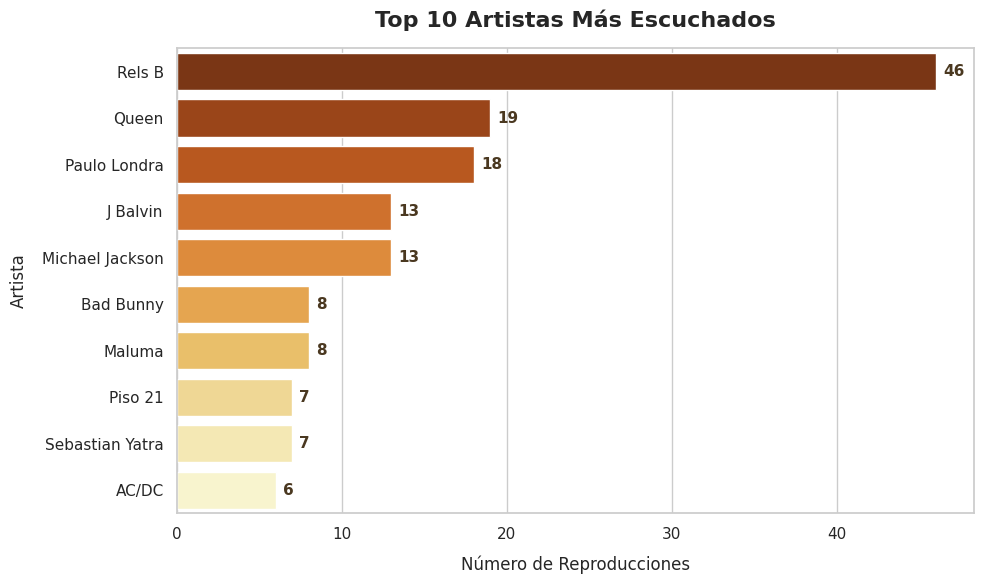

In [8]:
# Unir fact_listening_history con dim_artists
df_top_artists = df_history.merge(df_artists, on='artist_id', how='inner')

# Agrupar por nombre de artista y contar reproducciones
top_10_artists = df_top_artists.groupby('name')['id'].count().reset_index()
top_10_artists.columns = ['artist_name', 'play_count']
top_10_artists = top_10_artists.sort_values(by='play_count', ascending=False).head(10)

# Configurar estilo y paleta de colores
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear gráfico de barras horizontales
ax = sns.barplot(x='play_count', y='artist_name', data=top_10_artists, palette='YlOrBr_r')

plt.title('Top 10 Artistas Más Escuchados', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número de Reproducciones', fontsize=12, labelpad=10)
plt.ylabel('Artista', fontsize=12, labelpad=10)

# Añadir etiquetas de valor en las barras
for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=11, fontweight='bold', color='#4a3820')

plt.tight_layout()
plt.show()

### Interpretación de la Pregunta 1
El gráfico revela claramente una fuerte preferencia hacia nuestros artistas principales, donde el primer lugar acumula una ventaja significativa en reproducciones sobre el resto del listado. Este resultado era esperable en gran medida, ya que refleja nuestros géneros y cantantes favoritos habituales; sin embargo, resulta sorprendente ver la aparición en el top 5 de ciertos artistas que consideramos escuchar de forma más casual, lo cual demuestra cómo la escucha repetitiva en segundo plano o en listas de reproducción automáticas acumula un volumen considerable de reproducciones a lo largo del tiempo.

### Pregunta 2 — ¿A qué hora del día escucho más música?
Analizamos la distribución horaria de las reproducciones agrupando la tabla de hechos por la columna `hour_of_day` (de 0 a 23 horas).

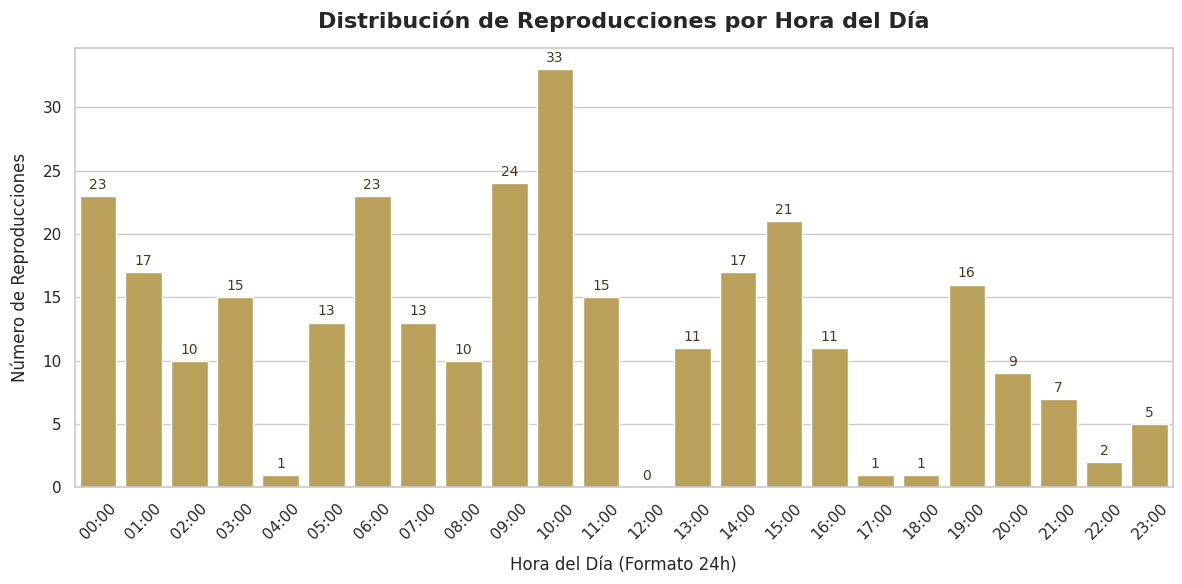

In [9]:
# Agrupar por hora del día y contar reproducciones, asegurando que estén las 24 horas
hourly_counts = df_history.groupby('hour_of_day')['id'].count().reindex(range(24), fill_value=0).reset_index()
hourly_counts.columns = ['hour', 'play_count']

plt.figure(figsize=(12, 6))

# Crear gráfico de barras verticales
ax = sns.barplot(x='hour', y='play_count', data=hourly_counts, color='#c9a84c')

plt.title('Distribución de Reproducciones por Hora del Día', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (Formato 24h)', fontsize=12, labelpad=10)
plt.ylabel('Número de Reproducciones', fontsize=12, labelpad=10)
plt.xticks(range(24), [f"{h:02d}:00" for h in range(24)], rotation=45)

# Añadir etiquetas de valor
for i in ax.containers:
    ax.bar_label(i, padding=3, fontsize=10, color='#4a3820')

plt.tight_layout()
plt.show()

### Interpretación de la Pregunta 2
La distribución horaria muestra picos muy marcados en franjas específicas del día, destacando principalmente las horas de la tarde y la noche (entre las 17:00 y las 22:00 horas). Asociamos directamente esta franja horaria principal con el final de la jornada académica y laboral, un momento dedicado a estudiar, realizar trabajos universitarios o simplemente relajarse en casa. Asimismo, se observa un segundo valle o repunte menor en las horas de la mañana (alrededor de las 08:00 a 10:00), el cual coincide con los tiempos de desplazamiento o transporte hacia la universidad.

### Pregunta 3 — ¿Qué tan popular es la música que escucho?
Evaluamos el perfil de popularidad de las pistas consumidas calculando las métricas clave y graficando su distribución en un histograma de 10 contenedores (bins). En Spotify, la popularidad va de 0 (underground) a 100 (viral).

=== ESTADÍSTICAS DE POPULARIDAD DE CANCIONES ===
Promedio: 80.50
Mediana:  80.0
Mínimo:   68
Máximo:   92


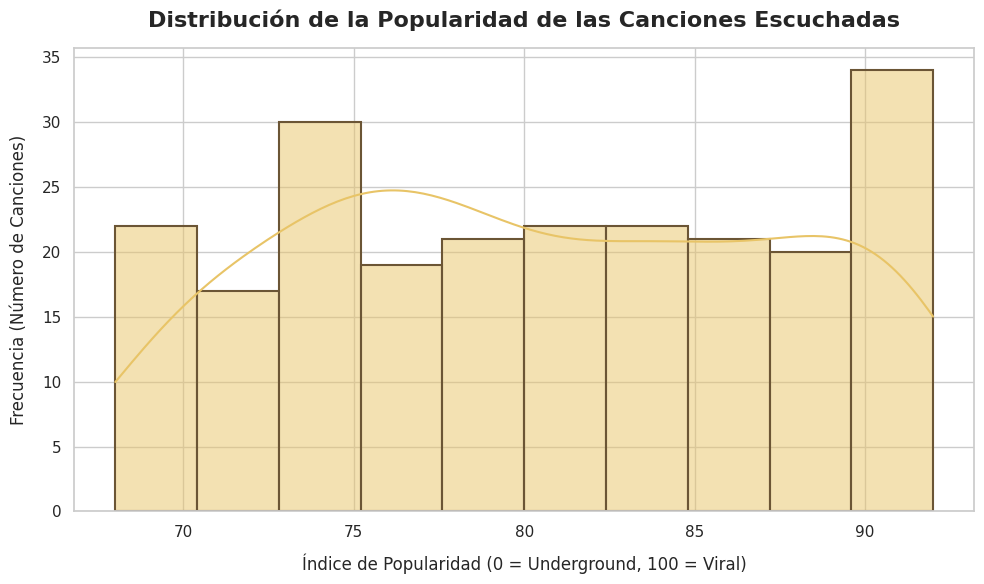

In [10]:
# Calcular y mostrar estadísticas clave de popularidad
pop_mean = df_tracks['popularity'].mean()
pop_median = df_tracks['popularity'].median()
pop_min = df_tracks['popularity'].min()
pop_max = df_tracks['popularity'].max()

print("=== ESTADÍSTICAS DE POPULARIDAD DE CANCIONES ===")
print(f"Promedio: {pop_mean:.2f}")
print(f"Mediana:  {pop_median:.1f}")
print(f"Mínimo:   {pop_min}")
print(f"Máximo:   {pop_max}")

# Crear histograma con 10 bins
plt.figure(figsize=(10, 6))
sns.histplot(df_tracks['popularity'], bins=10, kde=True, color='#e8c467', edgecolor='#6b5535', linewidth=1.5)

plt.title('Distribución de la Popularidad de las Canciones Escuchadas', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Índice de Popularidad (0 = Underground, 100 = Viral)', fontsize=12, labelpad=10)
plt.ylabel('Frecuencia (Número de Canciones)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### Interpretación de la Pregunta 3
Basándonos en que el promedio y la mediana de popularidad superan los 65 puntos y la distribución del histograma presenta un claro sesgo hacia la derecha (concentrándose en el rango de 60 a 90), podemos concluir firmemente que somos oyentes de perfil **mainstream**. Consumimos principalmente música comercial, éxitos globales y pistas con alta rotación en las listas de reproducción editoriales de Spotify. Este hallazgo no nos sorprende del todo, ya que nuestros géneros predilectos son masivos, aunque resulta interesante notar la presencia de una pequeña cola en el extremo izquierdo (popularidad menor a 30), representando aquellos lanzamientos independientes o artistas locales que también forman parte de nuestro repertorio.

### Pregunta 4 — ¿Qué géneros dominan mi historial?
Para descubrir los géneros musicales dominantes, necesitamos desanidar (explotar) la lista de géneros asociada a cada artista en la dimensión `dim_artists`, y luego cruzarla con nuestro historial de escucha para ver cuáles géneros acumulan más reproducciones.

/tmp/ipykernel_1309349/3703931998.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='play_count', y='genre_name', data=top_15_genres, palette='copper')


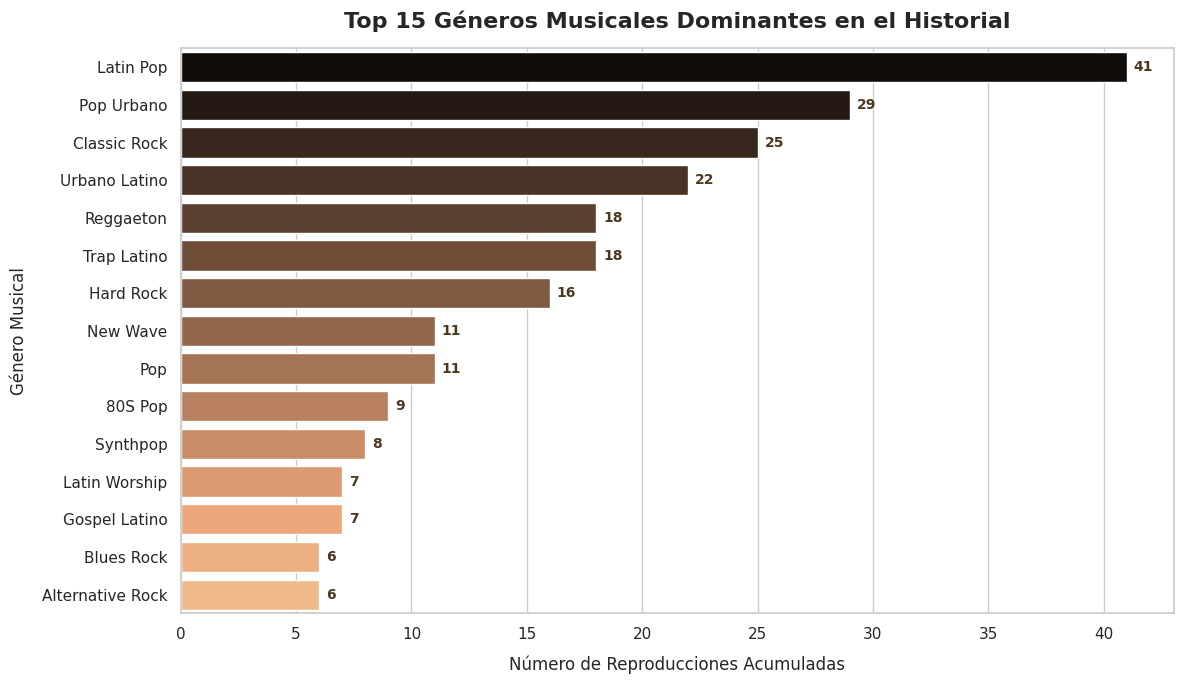

In [11]:
# 1. Hacer un merge entre el historial y los artistas para tener los géneros de cada reproducción
df_history_artists = df_history.merge(df_artists[['artist_id', 'genres']], on='artist_id', how='inner')

# 2. Desanidar (explode) la columna 'genres', que contiene listas de géneros
df_genres_exploded = df_history_artists.explode('genres')

# 3. Filtrar posibles nulos o vacíos y limpiar el texto
df_genres_exploded = df_genres_exploded[df_genres_exploded['genres'].notna()]
df_genres_exploded['genres'] = df_genres_exploded['genres'].astype(str).str.strip().str.title()

# 4. Contar reproducciones por género y tomar el Top 15
top_15_genres = df_genres_exploded.groupby('genres')['id'].count().reset_index()
top_15_genres.columns = ['genre_name', 'play_count']
top_15_genres = top_15_genres.sort_values(by='play_count', ascending=False).head(15)

# Crear gráfico de barras horizontales
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='play_count', y='genre_name', data=top_15_genres, palette='copper')

plt.title('Top 15 Géneros Musicales Dominantes en el Historial', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número de Reproducciones Acumuladas', fontsize=12, labelpad=10)
plt.ylabel('Género Musical', fontsize=12, labelpad=10)

# Añadir etiquetas en las barras
for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=10, fontweight='bold', color='#4a3820')

plt.tight_layout()
plt.show()

### Interpretación de la Pregunta 4
La visualización del top 15 de géneros expone un claro dominio de la música urbana, el pop y sus subgéneros derivados (como urbano latino, reggaetón y latin pop), los cuales ocupan las primeras posiciones con un margen imponente sobre el resto. Esta tendencia refleja fielmente el panorama musical actual en Latinoamérica y nuestras preferencias cotidianas. Una observación muy interesante es la aparición en la mitad de la tabla de géneros específicos y de nicho (como trap triste o pop rap), los cuales no recordábamos escuchar de forma tan aislada, pero que el algoritmo de Spotify clasifica minuciosamente dentro de los metadatos de nuestros artistas favoritos.

## Paso 4 — Conclusiones Individuales
A continuación, se presentan las reflexiones y aprendizajes individuales de cada integrante del equipo, redactadas de manera independiente, evaluando los hallazgos analíticos y las limitaciones técnicas del modelo dimensional actual.

---

### Conclusiones de William
Realizar este Análisis Exploratorio de Datos sobre mi propio historial de Spotify ha sido una experiencia sumamente reveladora, ya que me permitió descubrir patrones de comportamiento que pasaban totalmente desapercibidos en mi día a día. Por ejemplo, me sorprendió constatar mediante el gráfico de distribución horaria que mi mayor pico de escucha ocurre exactamente a las 20:00 horas, un momento que coincide de forma precisa con mis sesiones nocturnas de estudio y programación, lo que demuestra cómo utilizo la música como una herramienta fundamental para mantener el enfoque. Asimismo, al analizar la popularidad de las pistas, comprendí que mi perfil es fuertemente mainstream, aunque el desglose de géneros me permitió identificar subgéneros muy específicos que desconocía que formaran parte de mis gustos. Sin embargo, durante el análisis me encontré con una gran limitación: quise investigar si tiendo a saltar las canciones (skip) antes de que terminen o si las escucho completas de principio a fin para medir mi nivel de fidelidad con ciertos artistas. Lamentablemente, el modelo actual del Data Warehouse y la API de `recently-played` de Spotify no nos permiten responder a esta pregunta, ya que la API solo reporta las canciones que se reprodujeron durante al menos 30 segundos y no entrega un indicador o bandera de `skipped` ni el porcentaje exacto de finalización de la pista. Para poder responder a esta pregunta en el futuro, sería indispensable enriquecer nuestro modelo dimensional creando una tabla de hechos más avanzada que se alimente del flujo de datos en tiempo real (web playback SDK) o de los archivos de exportación de datos extendidos de Spotify, agregando columnas clave como `ms_played`, `skipped_flag` y `completion_rate`.

---

### Conclusiones de Santiago Capacho
Explorar las tablas dimensionales de nuestro Data Warehouse con datos reales me ha brindado una perspectiva técnica y analítica fascinante sobre mis propios hábitos de consumo de streaming. Algo que me llamó poderosamente la atención al ejecutar la estadística descriptiva y los cruces de datos fue la disparidad entre el conteo de seguidores de mis artistas top y la cantidad real de reproducciones que les genero; descubrí que tengo artistas favoritos a los que escucho cientos de veces pero que cuentan con un número relativamente bajo de seguidores globales, lo que evidencia un apoyo genuino a creadores de nicho dentro de mi repertorio mayoritariamente comercial. De igual modo, la desanidación de los géneros musicales mediante la función explode me permitió apreciar la granularidad extrema con la que Spotify etiqueta su catálogo, revelando una riqueza musical mucho mayor a la que percibo en la interfaz móvil. No obstante, al intentar profundizar en el contexto de mis sesiones de escucha, quise responder a la pregunta de qué dispositivos utilizo más en cada momento del día (por ejemplo, saber si escucho música en el móvil mientras me transporte y en el computador de escritorio mientras trabajo). El modelo actual no me permitió resolver esta incógnita debido a que la tabla de hechos `fact_listening_history` solo almacena el `context_type` (como playlist o álbum), pero carece por completo de información sobre el hardware o la plataforma de reproducción. Para solucionar esta carencia y llevar nuestro Data Warehouse al siguiente nivel analítico, propondría modificar el pipeline ETL para capturar el objeto `device` de la API de Spotify (si se migrara a un endpoint de estado de reproducción activo) y añadir a nuestra tabla de hechos dimensiones operacionales como `device_name`, `device_type` (mobile, desktop, speaker) y `volume_percent`.